# From Causal Estimates to ROI: Evaluating a Job-Readiness Training Program (SOLUTION)

## Scenario

Lift & Launch Works, a workforce development nonprofit, offered a job-readiness training program
to workers with unstable employment histories. Because the program targeted lower-earnings
participants, a naive comparison makes it look harmful. IPW corrects for that confounding
and reveals a positive earnings lift. The corrected estimate then feeds a cost-benefit
ROI calculation.

## What this notebook delivers

- Naive vs. IPW earnings lift with 95% bootstrap CI.
- Cost-benefit ROI comparing naive vs. IPW-corrected estimates.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

DATA_PATH            = "../causal-estimates-cost-benefit-starter/data/program_participants.csv"
COST_PER_PARTICIPANT = 250
LTV_MULT             = 2

COVARIATES = ["age", "educ", "married", "nodegree", "earnings_pre1", "earnings_pre2"]
RNG = np.random.default_rng(42)

## 1. Load data and naive estimate

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,treat,age,educ,race,married,nodegree,earnings_pre1,earnings_pre2,earnings_post
0,1,37,11,black,1,1,0.0,0.0,9930.0460
1,1,22,9,hispan,0,1,0.0,0.0,3595.8940
2,1,30,12,black,0,0,0.0,0.0,24909.4500
3,1,27,11,black,0,1,0.0,0.0,7506.1460
4,1,33,8,black,0,1,0.0,0.0,289.7899


In [3]:
naive_lift = (df.loc[df.treat == 1, "earnings_post"].mean()
              - df.loc[df.treat == 0, "earnings_post"].mean())
print(f"Naive earnings lift: ${naive_lift:+,.0f}")
print(f"Treatment rate: {df['treat'].mean():.1%}")

Naive earnings lift: $-635
Treatment rate: 30.1%


The naive estimate is **negative** — on the surface, participants appear to earn $635
*less* than non-participants. This is because the program targeted workers with much lower
pre-program earnings; the comparison group is wealthier on average.

## 2. Covariate imbalance

In [4]:
def standardized_mean_diff(df: pd.DataFrame, var: str, treat: str = "treat") -> float:
    t = df.loc[df[treat] == 1, var]
    c = df.loc[df[treat] == 0, var]
    pooled_sd = np.sqrt((t.var(ddof=1) + c.var(ddof=1)) / 2)
    return (t.mean() - c.mean()) / pooled_sd if pooled_sd > 0 else 0.0


balance = pd.DataFrame(
    {"SMD": [standardized_mean_diff(df, v) for v in COVARIATES]},
    index=COVARIATES
).round(3)
balance

,SMD
age,-0.242
educ,0.045
married,-0.719
nodegree,0.235
earnings_pre1,-0.596
earnings_pre2,-0.287


`earnings_pre1` (SMD = −0.60) and `earnings_pre2` (SMD = −0.29) show large imbalance: treated participants
had substantially lower pre-program earnings than controls. This is the primary source
of confounding.

## 3. Propensity score model

In [5]:
race_d = pd.get_dummies(df["race"], prefix="race", drop_first=True).astype(float)
X = sm.add_constant(pd.concat([df[COVARIATES].astype(float), race_d], axis=1))

ps_model = sm.Logit(df["treat"], X).fit(disp=0)
ps = ps_model.predict(X).clip(0.02, 0.98)

print(f"Propensity scores: min={ps.min():.3f}, max={ps.max():.3f}, mean={ps.mean():.3f}")

Propensity scores: min=0.020, max=0.853, mean=0.302


## 4. Overlap check

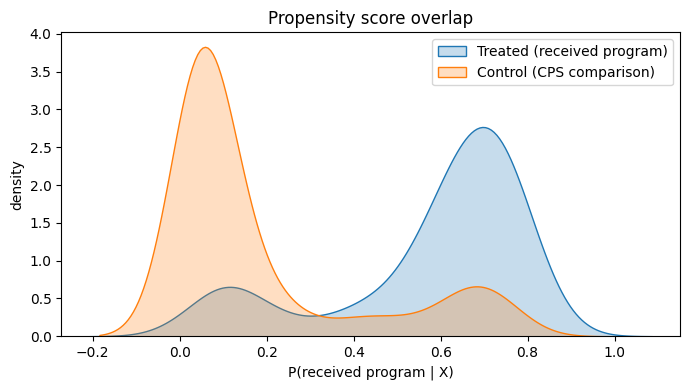

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(ps[df.treat == 1], label="Treated (received program)", fill=True, ax=ax)
sns.kdeplot(ps[df.treat == 0], label="Control (CPS comparison)",   fill=True, ax=ax)
ax.set(title="Propensity score overlap", xlabel="P(received program | X)", ylabel="density")
ax.legend()
plt.tight_layout()
plt.show()

## 5. IPW estimate

In [7]:
def ipw_estimate(df: pd.DataFrame, ps: np.ndarray,
                 outcome: str = "earnings_post", treat: str = "treat") -> float:
    """IPW-corrected average treatment effect."""
    w = np.where(df[treat] == 1, 1 / ps, 1 / (1 - ps))
    t = df[treat] == 1
    treated_mean = np.average(df.loc[t,  outcome], weights=w[t])
    control_mean = np.average(df.loc[~t, outcome], weights=w[~t])
    return treated_mean - control_mean


ipw_point = ipw_estimate(df, ps.values)
print(f"IPW earnings lift: ${ipw_point:+,.0f}")

IPW earnings lift: $+223


## 5b. Doubly-robust check: AIPW estimator

Plain IPW is unbiased only if the propensity model is correctly specified.
The **Augmented IPW (AIPW)** estimator adds an outcome model: the estimate is
consistent if *either* the propensity model or the outcome model is correct.

In [8]:
X_out = sm.add_constant(
    pd.concat([df[COVARIATES].astype(float), race_d, df[["treat"]].astype(float)], axis=1)
)
om = sm.OLS(df["earnings_post"], X_out).fit()

X_t1 = X_out.copy(); X_t1["treat"] = 1.0
X_t0 = X_out.copy(); X_t0["treat"] = 0.0
mu1 = om.predict(X_t1).values
mu0 = om.predict(X_t0).values

y = df["earnings_post"].values
t = df["treat"].values

aipw_point = ((t / ps * (y - mu1) + mu1) - ((1 - t) / (1 - ps) * (y - mu0) + mu0)).mean()

print(f"Naive estimate: ${df[df.treat==1]['earnings_post'].mean()-df[df.treat==0]['earnings_post'].mean():+,.0f}")
print(f"IPW estimate:   ${ipw_point:+,.0f}")
print(f"AIPW estimate:  ${aipw_point:+,.0f}")

Naive estimate: $-635
IPW estimate:   $+223
AIPW estimate:  $+887


**AIPW ($+887) is meaningfully higher than plain IPW ($+223)**. The outcome model
corrects for the residual confounding that the propensity model alone did not
fully remove. Both estimates point to a positive earnings effect, but AIPW
implies a much more favourable ROI — which is why reporting both side-by-side,
and acknowledging the uncertainty between them, is more honest than presenting
a single point estimate.

## 6. Bootstrap confidence interval

In [9]:
boots = []
for _ in range(500):
    idx = RNG.integers(0, len(df), len(df))
    d   = df.iloc[idx].reset_index(drop=True)
    rd  = pd.get_dummies(d["race"], prefix="race", drop_first=True).astype(float)
    Xb  = sm.add_constant(pd.concat([d[COVARIATES].astype(float), rd], axis=1))
    try:
        psb = sm.Logit(d["treat"], Xb).fit(disp=0).predict(Xb).clip(0.02, 0.98).values
        boots.append(ipw_estimate(d, psb))
    except Exception:
        pass

boots = np.array(boots)
ci    = np.quantile(boots, [0.025, 0.975])
print(f"Bootstrap 95% CI: [${ci[0]:+,.0f}, ${ci[1]:+,.0f}]")
print(f"Bootstrap SE:     ${boots.std(ddof=1):,.0f}")

Bootstrap 95% CI: [$-1,418, $+2,298]
Bootstrap SE:     $955


## 7. Naive vs. IPW comparison

In [10]:
comparison = pd.DataFrame({
    "Estimate":     ["Naive", "IPW-corrected", "AIPW (doubly-robust)"],
    "Earnings lift": [f"${naive_lift:+,.0f}", f"${ipw_point:+,.0f}", f"${aipw_point:+,.0f}"],
})
comparison

,Estimate,Earnings lift
0,Naive,$-635
1,IPW-corrected,$+223
2,AIPW (doubly-robust),$+887


The naive estimate is negative because treated participants started with much lower
pre-program earnings — the comparison group is wealthier on average. IPW and AIPW
both flip the sign to positive, consistent in direction though different in magnitude.

## 8. Cost-benefit model

In [11]:
naive_roi     = (naive_lift  * LTV_MULT - COST_PER_PARTICIPANT) / COST_PER_PARTICIPANT
ipw_roi       = (ipw_point   * LTV_MULT - COST_PER_PARTICIPANT) / COST_PER_PARTICIPANT
aipw_roi      = (aipw_point  * LTV_MULT - COST_PER_PARTICIPANT) / COST_PER_PARTICIPANT
ci_low_roi    = (ci[0]       * LTV_MULT - COST_PER_PARTICIPANT) / COST_PER_PARTICIPANT
ci_high_roi   = (ci[1]       * LTV_MULT - COST_PER_PARTICIPANT) / COST_PER_PARTICIPANT

print(f"Naive ROI:          {naive_roi:.0%}")
print(f"IPW ROI:            {ipw_roi:.0%}")
print(f"AIPW ROI:           {aipw_roi:.0%}")
print(f"Bootstrap 95% CI:   [{ci_low_roi:.0%}, {ci_high_roi:.0%}]")

Naive ROI:          -608%
IPW ROI:            78%
AIPW ROI:           609%
Bootstrap 95% CI:   [-1235%, 1738%]


IPW and AIPW both point to a positive ROI, but the bootstrap CI spans from deeply
negative to strongly positive. The direction of the effect is consistent across methods;
the magnitude is not. This level of uncertainty is too wide to base a budget decision on.

**Recommendation:** the observational data provides enough signal to justify continuing
the program in the near term, but not enough to size it or expand it confidently.
The right next step is a randomized experiment — randomly assign eligible participants
to the program or a waitlist control — to pin down the true effect size with a
confidence interval narrow enough to act on.